# GC Gold Breakout Backtest

This notebook implements the approved GC Globex breakout backtest as a production-style research workflow. The core engine lives in `gold_breakout_backtest.py`; the notebook keeps the analysis auditable by exposing each major stage, its diagnostics, and its validation outputs in sequence.

## Clarifications and Approved Decisions

- Backtest window is restricted to sessions starting on `2018-08-08 UTC`.
- The missing plan parameters are configurable and default to `fixed_ticks = 100` and `atr_multiplier_tpsl = 2.0`.
- Session boundaries are derived from the observed one-hour maintenance gap in the restricted sample because the UTC open shifts seasonally.
- Trigger evaluation uses adjusted levels; fills, transaction costs, and P&L stay in unadjusted price space.
- Open positions are rolled across dominant-contract changes, with rollover costs recorded separately and included in total trade costs.
- The hourly trailing-stop model is a structural upper bound on live win rate; every win-rate output should be read with that caveat in mind.


## 0. Configuration

All strategy, cost, risk, and file-path parameters live in one block. No downstream cell hardcodes strategy constants.


In [2]:
from pathlib import Path

from gold_breakout_backtest import (
    config_frame,
    make_default_config,
)

config = make_default_config(
    csv_path=Path("glbx-mdp3-20100606-20260325.ohlcv-1h.csv"),
    backtest_start_session_date="2018-08-08",
    starting_capital=100_000.0,
    risk_free_rate=0.04,
    min_session_volume=0,
    tp_sl_mode="symmetric_fixed", # "symmetric_fixed", "atr_based", "prior_day_range"
    fixed_ticks=100,
    atr_multiplier_tpsl=2.0, # default 2.0, higher values lead to wider stop losses and fewer trades, lower values lead to tighter stop losses and more trades (only used for atr_based tp_sl_mode)
    k=0.50, # default 0.50, 0.25 is more aggressive, 0.75 is more conservative (only used for prior_day_range tp_sl_mode)
    atr_period=14,
    atr_multiplier=0.50, # default 1.5, higher values lead to wider stop losses and fewer trades, lower values lead to tighter stop losses and more trades (always used for trailing stop losses)
    risk_fraction=0.01,
)

config_frame(config)


,parameter,value
0,csv_path,glbx-mdp3-20100606-20260325.ohlcv-1h.csv
1,backtest_start_session_date,2018-08-08
2,starting_capital,100000.0
3,risk_free_rate,0.04
4,max_ohlc_violations,0
5,min_session_volume,0
6,tp_sl_mode,symmetric_fixed
7,fixed_ticks,100
8,atr_multiplier_tpsl,2.0
9,k,0.5


## 1. Imports and Environment Setup

Only standard research dependencies are used here: `pandas`, `numpy`, `matplotlib`, and the local backtest module.


In [3]:
from time import perf_counter

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from gold_breakout_backtest import (
    plot_drawdown_curve,
    plot_equity_curve,
    plot_exit_reason_breakdown,
    plot_heatmap_grid,
    plot_monthly_returns_heatmap,
    plot_sizing_sensitivity_curve,
    plot_trade_pnl_distribution,
    plot_trail_sensitivity_curve,
    prepare_research_data,
    preview_signal_inputs,
    run_backtest,
    run_sensitivity_analysis,
    summarize_audit,
    with_atr_period,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 120


## 2. Data Ingestion and Validation

The loader enforces the raw CSV schema, filters out non-hourly rows and spreads, resolves duplicates deterministically, and records exclusions plus anomaly flags for review.


In [4]:
prepared = prepare_research_data(config)

display(summarize_audit(prepared.audit))
display(prepared.audit["frames"]["excluded_spreads"].head(10))
display(prepared.audit["frames"]["duplicate_resolution"].head(10))
display(prepared.audit["frames"]["low_volume_sessions_all_outrights"].head(10))


,metric,value
0,raw_rows,1244657
1,excluded_non_rtype_34,0
2,excluded_spread_rows,697405
3,ohlc_violation_count,0
4,duplicate_ts_instrument_rows,0
5,zero_volume_bar_count,0
6,low_liquidity_bar_count,102067
7,session_count_all_outrights,3005


,symbol
694561,GCF0-GCG0
706510,GCF0-GCH0
702146,GCF0-GCJ0
695962,GCF0-GCM0
28134,GCF1-GCG1
43360,GCF1-GCH1
41283,GCF1-GCJ1
783813,GCF1-GCM1
31358,GCF1-GCZ1
111384,GCF2-GCG2


,ts_event,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol,is_spread,selected


,session_id,session_open_ts,session_close_ts,session_bars,session_date,session_open_hour_utc,session_close_hour_utc,previous_session_id,session_total_volume


## 3. Continuous Series Construction

The dominant contract is selected by session-level volume, roll dates are logged, and a backward Panama adjustment is applied while preserving the unadjusted OHLC columns in parallel.


In [5]:
display(prepared.session_table.head(10))
display(prepared.audit["frames"]["roll_log"].head(10))
display(prepared.audit["frames"]["incomplete_or_irregular_sessions"].head(10))


,session_id,session_date,dominant_contract,dominant_volume,previous_dominant_contract,previous_dominant_volume,previous_session_id,roll_flag,session_open_ts,session_close_ts,session_bars,session_open_hour_utc,session_close_hour_utc,session_total_volume,continuous_session_bars,complete_session,first_bar_ts,last_bar_ts,first_close,last_close,first_open,outgoing_last_close,outgoing_last_bar_ts,roll_gap,roll_adjustment,adj_factor,previous_adj_factor,roll_continuity_error
0,1033,2018-08-08 00:00:00+00:00,GCZ8,222297,GCZ8,447203.0,1032.0,False,2018-08-08 22:00:00+00:00,2018-08-09 20:00:00+00:00,23,22,20,224952,23,True,2018-08-08 22:00:00+00:00,2018-08-09 20:00:00+00:00,1221.5,1220.0,1222.0,1221.8,2018-08-08 20:00:00+00:00,0.0,0.0,636.2,636.2,0.0
1,1034,2018-08-09 00:00:00+00:00,GCZ8,311942,GCZ8,222297.0,1033.0,False,2018-08-09 22:00:00+00:00,2018-08-10 20:00:00+00:00,23,22,20,315862,23,True,2018-08-09 22:00:00+00:00,2018-08-10 20:00:00+00:00,1219.4,1219.2,1220.0,1220.0,2018-08-09 20:00:00+00:00,0.0,0.0,636.2,636.2,0.0
2,1035,2018-08-12 00:00:00+00:00,GCZ8,358849,GCZ8,311942.0,1034.0,False,2018-08-12 22:00:00+00:00,2018-08-13 20:00:00+00:00,23,22,20,367340,23,True,2018-08-12 22:00:00+00:00,2018-08-13 20:00:00+00:00,1220.1,1200.5,1218.4,1219.2,2018-08-10 20:00:00+00:00,0.0,0.0,636.2,636.2,0.0
3,1036,2018-08-13 00:00:00+00:00,GCZ8,230127,GCZ8,358849.0,1035.0,False,2018-08-13 22:00:00+00:00,2018-08-14 20:00:00+00:00,23,22,20,233156,23,True,2018-08-13 22:00:00+00:00,2018-08-14 20:00:00+00:00,1201.5,1201.1,1201.1,1200.5,2018-08-13 20:00:00+00:00,0.0,0.0,636.2,636.2,0.0
4,1037,2018-08-14 00:00:00+00:00,GCZ8,359134,GCZ8,230127.0,1036.0,False,2018-08-14 22:00:00+00:00,2018-08-15 20:00:00+00:00,23,22,20,366318,23,True,2018-08-14 22:00:00+00:00,2018-08-15 20:00:00+00:00,1201.3,1181.8,1201.5,1201.1,2018-08-14 20:00:00+00:00,0.0,0.0,636.2,636.2,0.0
5,1038,2018-08-15 00:00:00+00:00,GCZ8,350694,GCZ8,359134.0,1037.0,False,2018-08-15 22:00:00+00:00,2018-08-16 20:00:00+00:00,23,22,20,356599,23,True,2018-08-15 22:00:00+00:00,2018-08-16 20:00:00+00:00,1182.5,1181.0,1183.0,1181.8,2018-08-15 20:00:00+00:00,0.0,0.0,636.2,636.2,0.0
6,1039,2018-08-16 00:00:00+00:00,GCZ8,243884,GCZ8,350694.0,1038.0,False,2018-08-16 22:00:00+00:00,2018-08-17 20:00:00+00:00,23,22,20,247382,23,True,2018-08-16 22:00:00+00:00,2018-08-17 20:00:00+00:00,1181.6,1191.8,1180.7,1181.0,2018-08-16 20:00:00+00:00,0.0,0.0,636.2,636.2,0.0
7,1040,2018-08-19 00:00:00+00:00,GCZ8,197220,GCZ8,243884.0,1039.0,False,2018-08-19 22:00:00+00:00,2018-08-20 20:00:00+00:00,23,22,20,200621,23,True,2018-08-19 22:00:00+00:00,2018-08-20 20:00:00+00:00,1190.1,1197.3,1190.4,1191.8,2018-08-17 20:00:00+00:00,0.0,0.0,636.2,636.2,0.0
8,1041,2018-08-20 00:00:00+00:00,GCZ8,209607,GCZ8,197220.0,1040.0,False,2018-08-20 22:00:00+00:00,2018-08-21 20:00:00+00:00,23,22,20,213124,23,True,2018-08-20 22:00:00+00:00,2018-08-21 20:00:00+00:00,1197.7,1202.7,1197.3,1197.3,2018-08-20 20:00:00+00:00,0.0,0.0,636.2,636.2,0.0
9,1042,2018-08-21 00:00:00+00:00,GCZ8,222948,GCZ8,209607.0,1041.0,False,2018-08-21 22:00:00+00:00,2018-08-22 20:00:00+00:00,23,22,20,226822,23,True,2018-08-21 22:00:00+00:00,2018-08-22 20:00:00+00:00,1203.1,1202.5,1203.0,1202.7,2018-08-21 20:00:00+00:00,0.0,0.0,636.2,636.2,0.0


,session_id,session_date,previous_dominant_contract,dominant_contract,previous_dominant_volume,dominant_volume,roll_gap,roll_continuity_error
9,9,2010-08-01 00:00:00+00:00,GCQ0,GCZ0,627850.0,409301,-2.2,0.0
29,29,2010-11-28 00:00:00+00:00,GCZ0,GCG1,99270.0,756069,4.3,0.0
39,39,2011-01-30 00:00:00+00:00,GCG1,GCJ1,812854.0,695453,-7.4,0.0
48,48,2011-03-27 00:00:00+00:00,GCJ1,GCM1,691435.0,652318,3.0,0.0
57,57,2011-05-29 00:00:00+00:00,GCM1,GCQ1,816910.0,13153,-2.3,0.0
68,68,2011-07-31 00:00:00+00:00,GCQ1,GCZ1,676827.0,975477,9.1,0.0
87,87,2011-11-27 00:00:00+00:00,GCZ1,GCG2,99485.0,652462,-16.5,0.0
97,97,2012-01-29 00:00:00+00:00,GCG2,GCJ2,840628.0,699961,-2.9,0.0
107,107,2012-04-01 00:00:00+00:00,GCJ2,GCM2,575113.0,543905,-8.0,0.0
116,116,2012-05-28 00:00:00+00:00,GCM2,GCQ2,57988.0,851515,-2.4,0.0


,session_id,session_date,continuous_session_bars,dominant_contract,session_total_volume
0,0,2010-06-06 00:00:00+00:00,120,GCQ0,613041
1,1,2010-06-13 00:00:00+00:00,120,GCQ0,550007
2,2,2010-06-20 00:00:00+00:00,120,GCQ0,641399
3,3,2010-06-27 00:00:00+00:00,119,GCQ0,805409
4,4,2010-07-04 00:00:00+00:00,20,GCQ0,20826
5,5,2010-07-05 00:00:00+00:00,96,GCQ0,524447
6,6,2010-07-11 00:00:00+00:00,120,GCQ0,619630
7,7,2010-07-18 00:00:00+00:00,120,GCQ0,821662
8,8,2010-07-25 00:00:00+00:00,120,GCQ0,1284219
9,9,2010-08-01 00:00:00+00:00,120,GCZ0,459272


## 4. Feature Engineering

This stage creates previous-session breakout levels, previous-session range, true range, and the shifted Wilder ATR used by the strategy.


In [6]:
feature_prepared = with_atr_period(prepared, config.atr_period)

feature_prepared.continuous_data[
    [
        "ts_event",
        "session_date",
        "dominant_contract",
        "adj_open",
        "adj_high",
        "adj_low",
        "adj_close",
        "prev_session_high",
        "prev_session_low",
        "prev_session_range",
        "true_range",
        "atr",
    ]
].head(15)


,ts_event,session_date,dominant_contract,adj_open,adj_high,adj_low,adj_close,prev_session_high,prev_session_low,prev_session_range,true_range,atr
0,2018-08-08 22:00:00+00:00,2018-08-08 00:00:00+00:00,GCZ8,1858.2,1858.3,1857.1,1857.7,1860.5,1849.8,10.7,1.2,NaN
1,2018-08-08 23:00:00+00:00,2018-08-08 00:00:00+00:00,GCZ8,1857.7,1858.0,1857.2,1857.4,1860.5,1849.8,10.7,0.8,NaN
2,2018-08-09 00:00:00+00:00,2018-08-08 00:00:00+00:00,GCZ8,1857.3,1858.8,1857.3,1858.5,1860.5,1849.8,10.7,1.5,NaN
3,2018-08-09 01:00:00+00:00,2018-08-08 00:00:00+00:00,GCZ8,1858.4,1859.0,1856.3,1857.3,1860.5,1849.8,10.7,2.7,NaN
4,2018-08-09 02:00:00+00:00,2018-08-08 00:00:00+00:00,GCZ8,1857.3,1859.7,1857.2,1858.9,1860.5,1849.8,10.7,2.5,NaN
5,2018-08-09 03:00:00+00:00,2018-08-08 00:00:00+00:00,GCZ8,1858.8,1859.5,1858.2,1859.0,1860.5,1849.8,10.7,1.3,NaN
6,2018-08-09 04:00:00+00:00,2018-08-08 00:00:00+00:00,GCZ8,1859.0,1859.5,1858.4,1858.5,1860.5,1849.8,10.7,1.1,NaN
7,2018-08-09 05:00:00+00:00,2018-08-08 00:00:00+00:00,GCZ8,1858.5,1859.2,1857.7,1859.2,1860.5,1849.8,10.7,1.5,NaN
8,2018-08-09 06:00:00+00:00,2018-08-08 00:00:00+00:00,GCZ8,1859.1,1861.8,1857.5,1858.0,1860.5,1849.8,10.7,4.3,NaN
9,2018-08-09 07:00:00+00:00,2018-08-08 00:00:00+00:00,GCZ8,1857.9,1858.1,1854.6,1855.5,1860.5,1849.8,10.7,3.5,NaN


## 5. Signal Generation

Signals are prepared from session-open inputs only. The actual trigger sequence remains path-dependent and is handled inside the sequential engine, but this preview makes the daily order setup auditable.


In [7]:
signal_preview = preview_signal_inputs(feature_prepared, config, rows=15)
signal_preview


,ts_event,session_date,dominant_contract,prev_session_high,prev_session_low,prev_session_range,atr,sl_distance_price,adj_factor
0,2018-08-08 22:00:00+00:00,2018-08-08 00:00:00+00:00,GCZ8,1860.5,1849.8,10.7,NaN,10.0,636.2
1,2018-08-09 22:00:00+00:00,2018-08-09 00:00:00+00:00,GCZ8,1861.8,1854.6,7.2,1.852997,10.0,636.2
2,2018-08-12 22:00:00+00:00,2018-08-12 00:00:00+00:00,GCZ8,1861.1,1849.3,11.8,2.330434,10.0,636.2
3,2018-08-13 22:00:00+00:00,2018-08-13 00:00:00+00:00,GCZ8,1857.6,1834.8,22.8,2.726104,10.0,636.2
4,2018-08-14 22:00:00+00:00,2018-08-14 00:00:00+00:00,GCZ8,1842.0,1835.1,6.9,1.954119,10.0,636.2
5,2018-08-15 22:00:00+00:00,2018-08-15 00:00:00+00:00,GCZ8,1838.2,1816.2,22.0,2.887072,10.0,636.2
6,2018-08-16 22:00:00+00:00,2018-08-16 00:00:00+00:00,GCZ8,1825.2,1803.3,21.9,3.337920,10.0,636.2
7,2018-08-19 22:00:00+00:00,2018-08-19 00:00:00+00:00,GCZ8,1828.2,1814.7,13.5,2.750295,10.0,636.2
8,2018-08-20 22:00:00+00:00,2018-08-20 00:00:00+00:00,GCZ8,1833.9,1825.8,8.1,2.202098,10.0,636.2
9,2018-08-21 22:00:00+00:00,2018-08-21 00:00:00+00:00,GCZ8,1840.5,1830.5,10.0,2.389969,10.0,636.2


## 6. Portfolio and Execution Engine

The engine processes sessions chronologically, updates trailing stops bar by bar, supports concurrent long and short positions, rolls open positions across contract changes, and records a full trade lifecycle.


In [ ]:
backtest_start = perf_counter()
result = run_backtest(feature_prepared, config)
backtest_elapsed = perf_counter() - backtest_start
print(f"Backtest runtime: {backtest_elapsed:.2f} seconds")

trade_log, roll_events, order_cancellations = result.trade_log, result.roll_events, result.order_cancellations # so i can view with dataWrangler

display(trade_log.tail(10))
display(roll_events.head(10))
display(order_cancellations.head(10))


Backtest runtime: 3.77 seconds


,trade_id,direction,entry_bar_ts,entry_session_id,entry_session_date,entry_price,contracts,tp_price,initial_sl_price,current_trail_stop,tp_price_adj,initial_sl_price_adj,current_trail_stop_adj,status,exit_price,exit_bar_ts,exit_reason,gross_pnl,transaction_cost,net_pnl,entry_fill_basis,exit_fill_basis,bars_held,roll_count,roll_cost,sizing_equity,risk_per_trade,floor_applied,sl_distance_price,sl_distance_usd,current_contract_at_exit,incremental_gross_pnl,incremental_net_pnl
1886,1887,long,2026-03-10 13:00:00+00:00,2992,2026-03-09 00:00:00+00:00,5210.5,16,5220.5,5200.5,5210.747277,5220.5,5200.5,5210.747277,closed,5210.647277,2026-03-10 14:00:00+00:00,trail_stop,235.642925,395.84,-160.197075,unadjusted_stop_plus_tick_entry,unadjusted_stop_minus_tick_exit,1,0,0.0,1.658497e+06,16584.968081,False,10.0,1000.0,GCJ6,235.642925,-160.197075
1887,1888,short,2026-03-11 22:00:00+00:00,2994,2026-03-11 00:00:00+00:00,5155.8,16,5145.8,5165.8,5150.498198,5145.8,5165.8,5150.498198,closed,5150.598198,2026-03-11 23:00:00+00:00,trail_stop,8322.883533,395.84,7927.043533,unadjusted_stop_minus_tick_entry,unadjusted_stop_plus_tick_exit,1,0,0.0,1.658337e+06,16583.366110,False,10.0,1000.0,GCJ6,8322.883533,7927.043533
1888,1889,short,2026-03-13 14:00:00+00:00,2995,2026-03-12 00:00:00+00:00,5058.1,16,5048.1,5068.1,5044.574354,5048.1,5068.1,5044.574354,closed,5044.674354,2026-03-13 15:00:00+00:00,trail_stop,21481.033628,395.84,21085.193628,unadjusted_stop_minus_tick_entry,unadjusted_stop_plus_tick_exit,1,0,0.0,1.666264e+06,16662.636546,False,10.0,1000.0,GCJ6,21481.033628,21085.193628
1889,1890,short,2026-03-15 22:00:00+00:00,2996,2026-03-15 00:00:00+00:00,5010.0,16,5000.0,5020.0,4983.181304,5000.0,5020.0,4983.181304,closed,4983.281304,2026-03-15 23:00:00+00:00,trail_stop,42749.913006,395.84,42354.073006,unadjusted_open_gap_entry,unadjusted_stop_plus_tick_exit,1,0,0.0,1.687349e+06,16873.488482,False,10.0,1000.0,GCJ6,42749.913006,42354.073006
1890,1891,long,2026-03-17 04:00:00+00:00,2997,2026-03-16 00:00:00+00:00,5044.6,17,5054.6,5034.6,5038.130999,5054.6,5034.6,5038.130999,closed,5038.030999,2026-03-17 05:00:00+00:00,trail_stop,-11167.301274,420.58,-11587.881274,unadjusted_stop_plus_tick_entry,unadjusted_stop_minus_tick_exit,1,0,0.0,1.729703e+06,17297.029212,False,10.0,1000.0,GCJ6,-11167.301274,-11587.881274
1891,1892,short,2026-03-18 10:00:00+00:00,2998,2026-03-17 00:00:00+00:00,4976.9,17,4966.9,4986.9,4937.498834,4966.9,4986.9,4937.498834,closed,4937.598834,2026-03-18 11:00:00+00:00,trail_stop,66811.982057,420.58,66391.402057,unadjusted_stop_minus_tick_entry,unadjusted_stop_plus_tick_exit,1,0,0.0,1.718115e+06,17181.150399,False,10.0,1000.0,GCJ6,66811.982057,66391.402057
1892,1893,short,2026-03-18 22:00:00+00:00,2999,2026-03-18 00:00:00+00:00,4809.2,17,4799.2,4819.2,4819.200000,4799.2,4819.2,4819.200000,closed,4819.300000,2026-03-18 23:00:00+00:00,initial_sl,-17170.000000,420.58,-17590.580000,unadjusted_stop_minus_tick_entry,unadjusted_stop_plus_tick_exit,1,0,0.0,1.784506e+06,17845.064420,False,10.0,1000.0,GCJ6,-17170.000000,-17590.580000
1893,1894,short,2026-03-20 18:00:00+00:00,3000,2026-03-19 00:00:00+00:00,4504.9,17,4494.9,4514.9,4512.174093,4494.9,4514.9,4512.174093,closed,4512.274093,2026-03-20 19:00:00+00:00,trail_stop,-12535.958611,420.58,-12956.538611,unadjusted_stop_minus_tick_entry,unadjusted_stop_plus_tick_exit,1,0,0.0,1.766916e+06,17669.158620,False,10.0,1000.0,GCJ6,-12535.958611,-12956.538611
1894,1895,short,2026-03-22 22:00:00+00:00,3001,2026-03-22 00:00:00+00:00,4450.0,17,4440.0,4460.0,4460.000000,4440.0,4460.0,4460.000000,closed,4460.100000,2026-03-22 23:00:00+00:00,initial_sl,-17170.000000,420.58,-17590.580000,unadjusted_open_gap_entry,unadjusted_stop_plus_tick_exit,1,0,0.0,1.753959e+06,17539.593234,False,10.0,1000.0,GCJ6,-17170.000000,-17590.580000
1895,1896,long,2026-03-24 22:00:00+00:00,3003,2026-03-24 00:00:00+00:00,4485.7,17,4495.7,4475.7,4528.786086,4495.7,4475.7,4528.786086,closed,4528.686086,2026-03-24 23:00:00+00:00,trail_stop,730

""


,session_id,session_date,direction,cancel_ts,stop_level_adj
0,1033,2018-08-08 00:00:00+00:00,short,2018-08-09 20:00:00+00:00,1849.8
1,1034,2018-08-09 00:00:00+00:00,long,2018-08-10 20:00:00+00:00,1861.8
2,1035,2018-08-12 00:00:00+00:00,long,2018-08-13 20:00:00+00:00,1861.1
3,1036,2018-08-13 00:00:00+00:00,long,2018-08-14 20:00:00+00:00,1857.6
4,1036,2018-08-13 00:00:00+00:00,short,2018-08-14 20:00:00+00:00,1834.8
5,1037,2018-08-14 00:00:00+00:00,long,2018-08-15 20:00:00+00:00,1842.0
6,1038,2018-08-15 00:00:00+00:00,long,2018-08-16 20:00:00+00:00,1838.2
7,1039,2018-08-16 00:00:00+00:00,short,2018-08-17 20:00:00+00:00,1803.3
8,1040,2018-08-19 00:00:00+00:00,short,2018-08-20 20:00:00+00:00,1814.7
9,1041,2018-08-20 00:00:00+00:00,short,2018-08-21 20:00:00+00:00,1825.8


## 7. Transaction Cost Model

Round-turn costs are applied at the trade level, and rollover costs are added for trades that survive dominant-contract changes.


In [9]:
cost_summary = result.performance_summary[
    [
        "gross_total_pnl",
        "net_total_pnl",
        "total_cost_drag",
        "cost_drag_pct_of_gross",
        "sizing_floor_events",
    ]
]

cost_summary.to_frame("value")


,value
gross_total_pnl,1.816619e+06
net_total_pnl,1.709025e+06
total_cost_drag,1.075943e+05
cost_drag_pct_of_gross,5.922776e+00
sizing_floor_events,1.000000e+00


## 8. Backtest Loop Diagnostics

This view focuses on the chronological engine diagnostics: skipped sessions, concurrency, and margin flags.


In [15]:
simul_shortlong = result.diagnostics["concurrency_log"] # so i can view with dataWrangler

display(result.skipped_sessions.head(10))
display(result.margin_flags.head(10))
display(result.diagnostics["session_sizing"].head(10))
display(result.diagnostics["concurrency_log"].head(10))

""


,session_id,session_date,ts_event,open_contracts,open_positions
0,2200,2023-02-13 00:00:00+00:00,2023-02-14 13:00:00+00:00,4,2
1,2284,2023-06-12 00:00:00+00:00,2023-06-13 12:00:00+00:00,4,2
2,2322,2023-08-03 00:00:00+00:00,2023-08-04 12:00:00+00:00,4,2
3,2495,2024-04-07 00:00:00+00:00,2024-04-08 02:00:00+00:00,3,1
4,2496,2024-04-08 00:00:00+00:00,2024-04-09 07:00:00+00:00,3,1
5,2497,2024-04-09 00:00:00+00:00,2024-04-10 12:00:00+00:00,3,1
6,2498,2024-04-10 00:00:00+00:00,2024-04-11 18:00:00+00:00,3,1
7,2499,2024-04-11 00:00:00+00:00,2024-04-11 22:00:00+00:00,3,1
8,2500,2024-04-14 00:00:00+00:00,2024-04-15 14:00:00+00:00,3,1
9,2501,2024-04-15 00:00:00+00:00,2024-04-15 22:00:00+00:00,3,1


,session_id,session_date,session_open_equity,risk_per_trade,contracts,floor_applied,sl_distance_price,sl_distance_usd
0,1033,2018-08-08 00:00:00+00:00,100000.000000,1000.000000,1,False,10.0,1000.0
1,1034,2018-08-09 00:00:00+00:00,99934.902857,999.349029,1,True,10.0,1000.0
2,1035,2018-08-12 00:00:00+00:00,100329.960352,1003.299604,1,False,10.0,1000.0
3,1036,2018-08-13 00:00:00+00:00,100397.511755,1003.975118,1,False,10.0,1000.0
4,1037,2018-08-14 00:00:00+00:00,100397.511755,1003.975118,1,False,10.0,1000.0
5,1038,2018-08-15 00:00:00+00:00,100323.323884,1003.233239,1,False,10.0,1000.0
6,1039,2018-08-16 00:00:00+00:00,101050.355082,1010.503551,1,False,10.0,1000.0
7,1040,2018-08-19 00:00:00+00:00,101165.983815,1011.659838,1,False,10.0,1000.0
8,1041,2018-08-20 00:00:00+00:00,101004.953764,1010.049538,1,False,10.0,1000.0
9,1042,2018-08-21 00:00:00+00:00,101209.051866,1012.090519,1,False,10.0,1000.0


,ts_event,session_id,open_positions,open_contracts,simultaneous_long_short
0,2018-08-08 22:00:00+00:00,1033,0,0,False
1,2018-08-08 23:00:00+00:00,1033,0,0,False
2,2018-08-09 00:00:00+00:00,1033,0,0,False
3,2018-08-09 01:00:00+00:00,1033,0,0,False
4,2018-08-09 02:00:00+00:00,1033,0,0,False
5,2018-08-09 03:00:00+00:00,1033,0,0,False
6,2018-08-09 04:00:00+00:00,1033,0,0,False
7,2018-08-09 05:00:00+00:00,1033,0,0,False
8,2018-08-09 06:00:00+00:00,1033,1,1,False
9,2018-08-09 07:00:00+00:00,1033,1,1,False


## 9. Performance Analytics

The summary includes headline return, drawdown, risk-adjusted metrics, trade statistics, direction splits, and annual breakdowns.


In [11]:
display(result.performance_summary.to_frame("value"))
display(result.direction_summary)
display(result.annual_summary)
display(result.exit_breakdown)


,value
terminal_gross_equity,1.916619e+06
terminal_net_equity,1.809025e+06
total_return_pct,1.709025e+03
annualized_return_pct,4.618829e+01
max_drawdown_pct,5.996584e+00
max_drawdown_duration_sessions,7.500000e+01
sharpe_ratio,2.985866e+00
sortino_ratio,1.068482e+01
calmar_ratio,7.702435e+00
total_trades,1.896000e+03


,direction,trades,win_rate_pct,gross_pnl,net_pnl,avg_win_usd,avg_loss_usd,profit_factor,avg_bars_held
0,long,1031,48.593598,1.045547e+06,985403.569978,2776.306875,-765.143725,3.778431,1.046557
1,short,865,45.780347,7.710723e+05,723620.939548,2802.453974,-823.349327,3.133652,1.033526


,year,start_equity,end_equity,annual_return_pct,trade_count,win_rate_pct
0,2018,99934.902857,1.032729e+05,3.340150,93,40.860215
1,2019,103423.570906,1.196028e+05,15.643632,239,43.933054
2,2020,119854.002205,1.574703e+05,31.385117,257,48.249027
3,2021,158183.307231,1.764078e+05,11.521146,250,44.000000
4,2022,177249.052807,2.075979e+05,17.122161,254,48.818898
5,2023,208260.938752,2.863339e+05,37.488040,247,46.963563
6,2024,285403.871314,4.119722e+05,44.347106,249,45.783133
7,2025,412912.598357,8.514459e+05,106.204870,252,53.968254
8,2026,851140.250577,1.809025e+06,112.541295,55,54.545455


,exit_reason,count,pct
0,trail_stop,1879,99.103376
1,initial_sl,14,0.738397
2,tp,3,0.158228


## 10. Visualization

Plots focus on analytical clarity: realized equity, drawdown, monthly returns, P&L distributions, and exit composition.


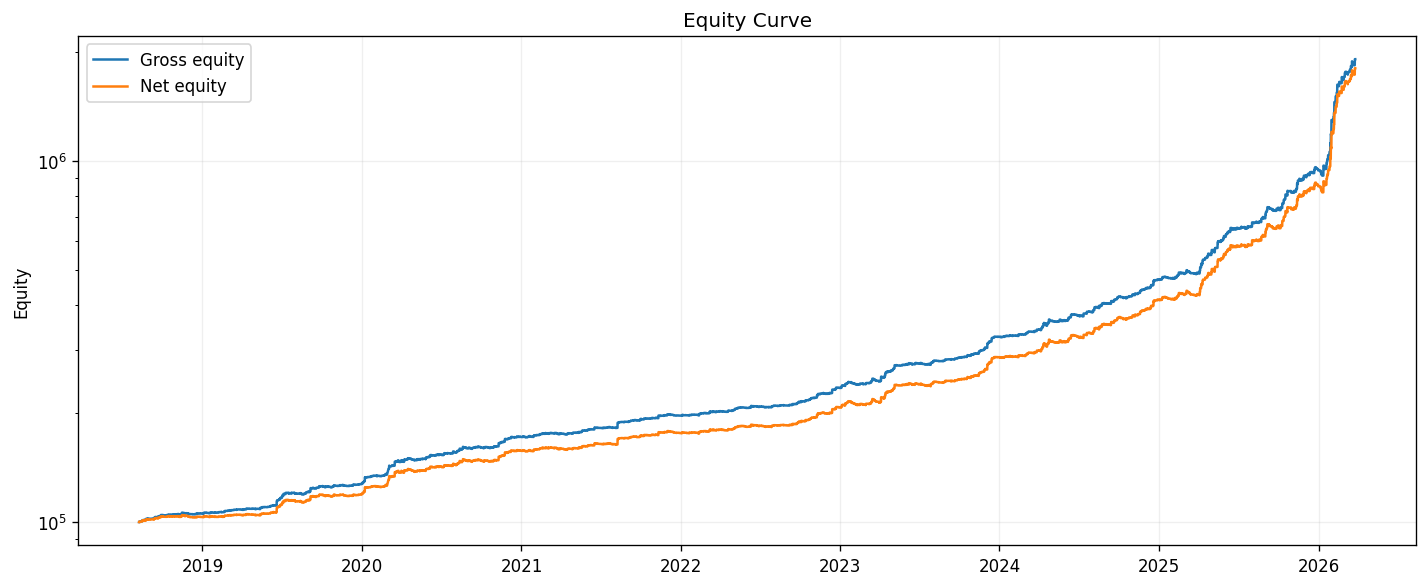

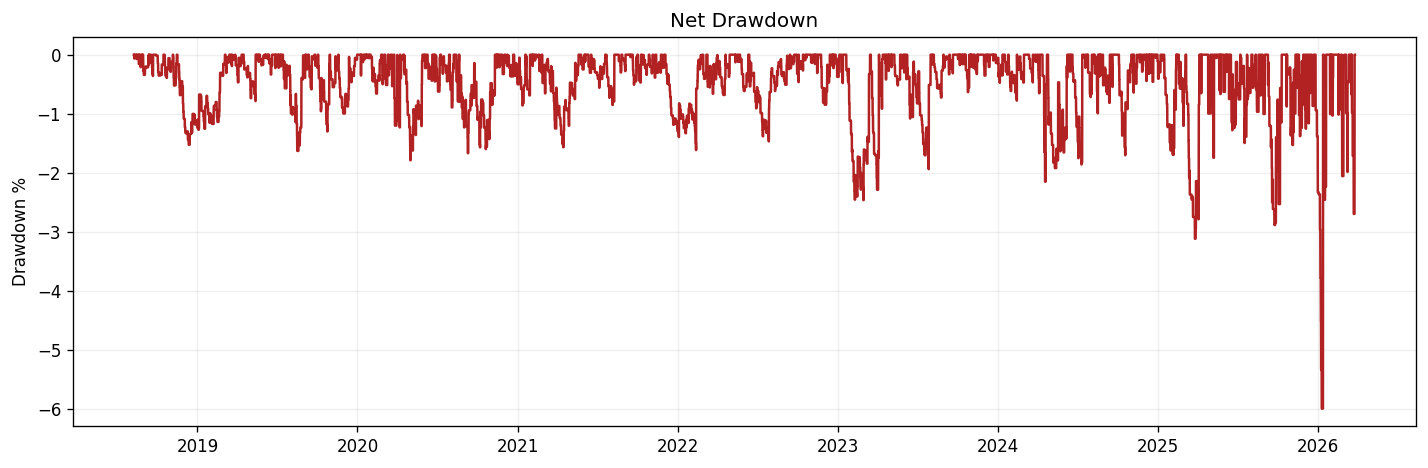

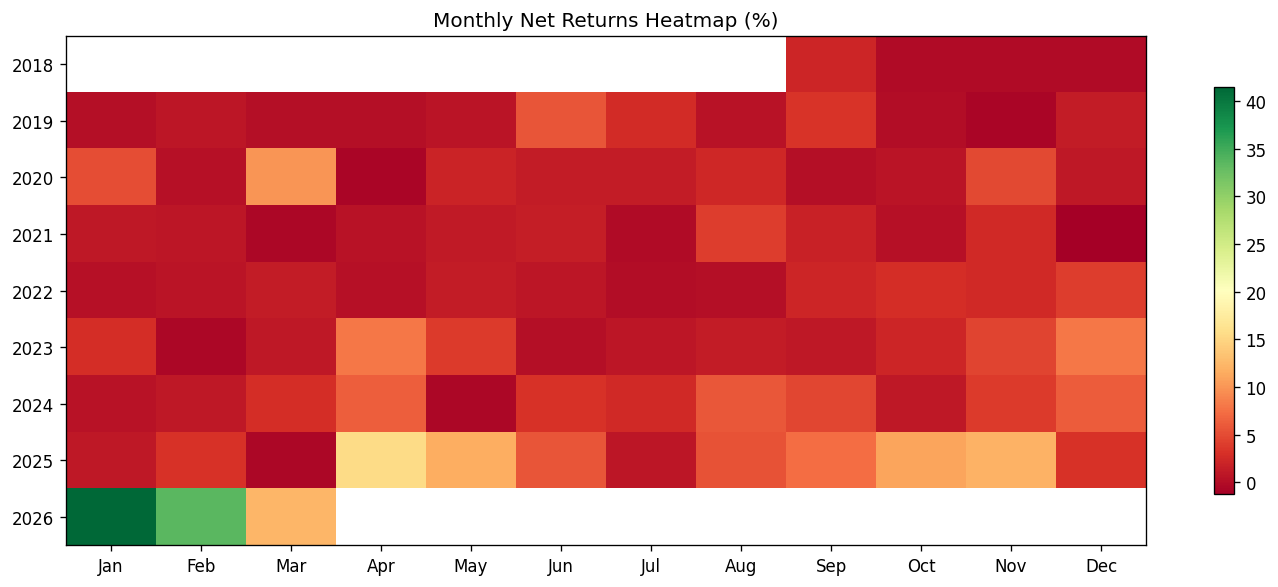

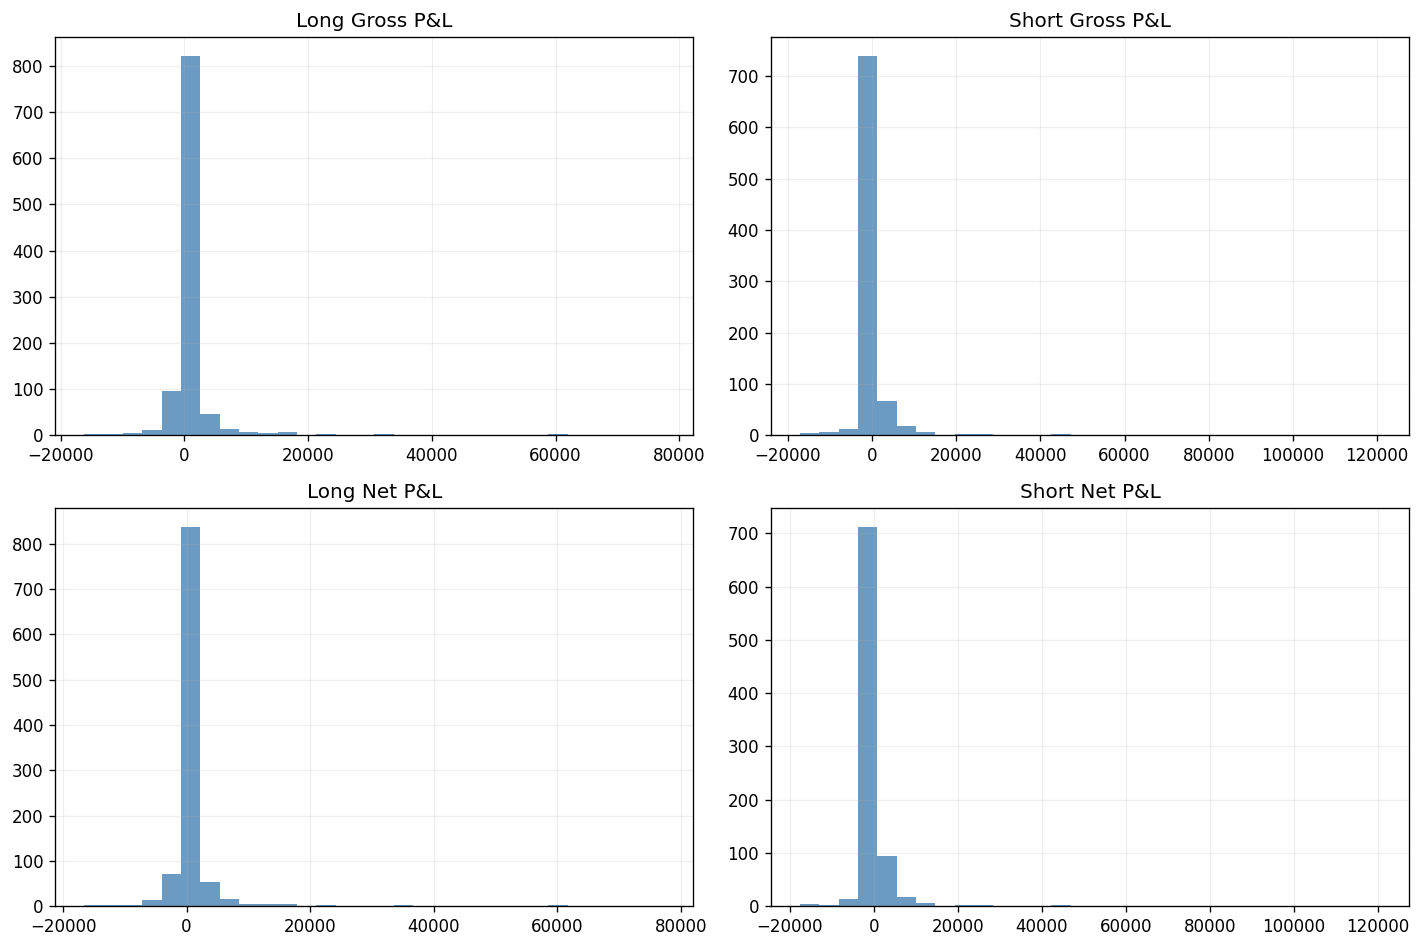

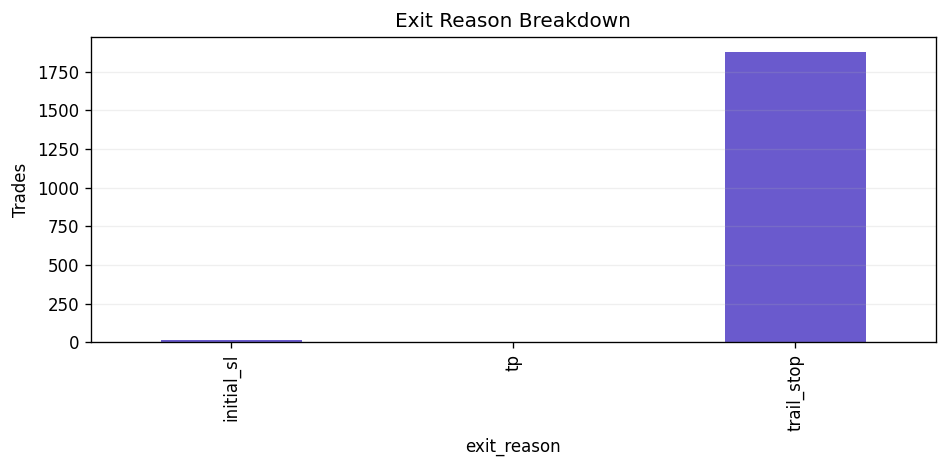

In [12]:
for figure in [
    plot_equity_curve(result),
    plot_drawdown_curve(result),
    plot_monthly_returns_heatmap(result),
    plot_trade_pnl_distribution(result),
    plot_exit_reason_breakdown(result),
]:
    display(figure)
    plt.close(figure)


## 11. Sensitivity Analysis

The primary grid reports `atr_multiplier × k` heatmaps by `tp_sl_mode`. For `symmetric_fixed` and `atr_based`, the `k` axis is intentionally repeated because the mode does not consume `k`, but the output shape is kept identical for comparison.

Interpretation note:

- A sharp single-cell optimum is evidence of overfitting risk.
- A broad plateau is evidence of robustness.


Sensitivity runtime: 382.08 seconds


,atr_period,tp_sl_mode,atr_multiplier,k,win_rate,profit_factor,sharpe_ratio,max_drawdown_pct,terminal_net_equity,total_return_pct,total_trades
0,7,symmetric_fixed,0.5,0.25,47.046414,3.260680,2.808924,5.578564,1.412594e+06,1312.593589,1896.0
1,7,symmetric_fixed,0.5,0.50,47.046414,3.260680,2.808924,5.578564,1.412594e+06,1312.593589,1896.0
2,7,symmetric_fixed,0.5,0.75,47.046414,3.260680,2.808924,5.578564,1.412594e+06,1312.593589,1896.0
3,7,symmetric_fixed,0.5,1.00,47.046414,3.260680,2.808924,5.578564,1.412594e+06,1312.593589,1896.0
4,7,symmetric_fixed,1.0,0.25,36.761603,0.917041,-0.253054,103.364071,1.584696e+04,-84.153039,1896.0
5,7,symmetric_fixed,1.0,0.50,36.761603,0.917041,-0.253054,103.364071,1.584696e+04,-84.153039,1896.0
6,7,symmetric_fixed,1.0,0.75,36.761603,0.917041,-0.253054,103.364071,1.584696e+04,-84.153039,1896.0
7,7,symmetric_fixed,1.0,1.00,36.761603,0.917041,-0.253054,103.364071,1.584696e+04,-84.153039,1896.0
8,7,symmetric_fixed,1.5,0.25,35.337553,0.739077,0.254724,200.232408,-1.007178e+05,-200.717800,1896.0
9,7,symmetric_fixed,1.5,0.50,35.337553,0.739077,0.254724,200.232408,-1.007178e+05,-200.717800,1896.0


,risk_fraction,terminal_net_equity,max_drawdown_pct,sharpe_ratio,total_return_pct,total_trades
0,0.005,4.933502e+05,1.788997,2.872648,393.350205,1896.0
1,0.010,1.809025e+06,5.996584,2.985866,1709.024510,1896.0
2,0.020,6.533350e+07,12.367790,3.278548,65233.498965,1896.0


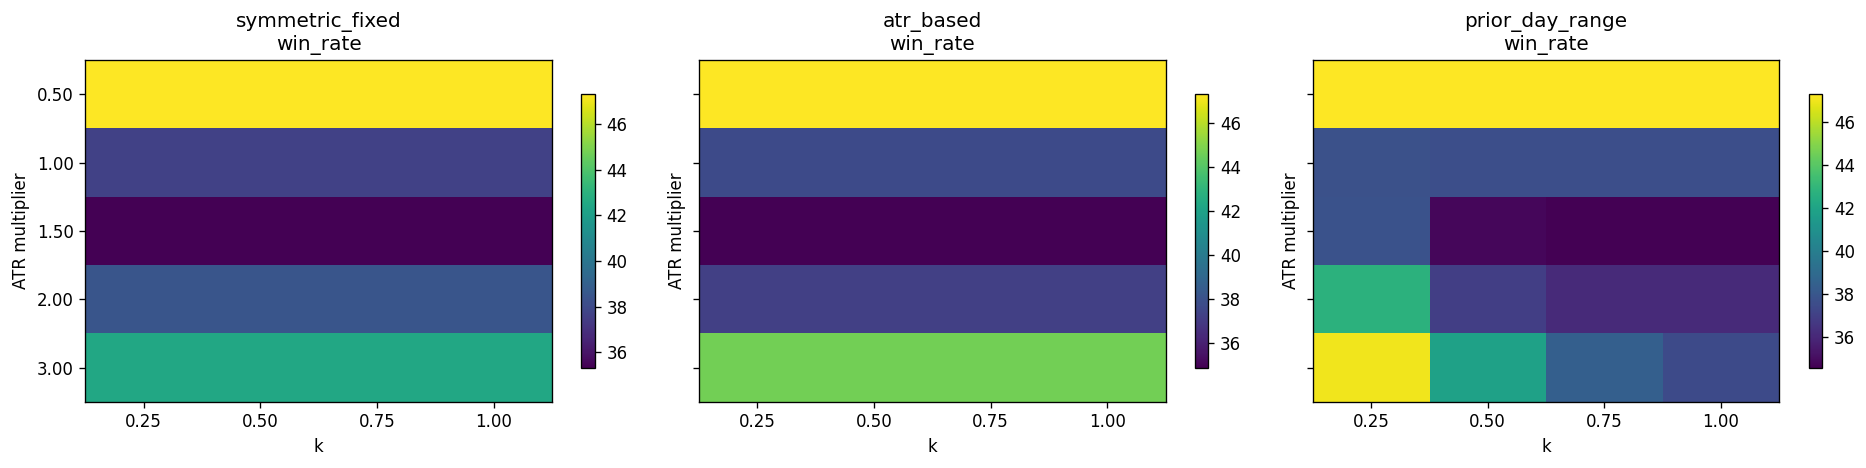

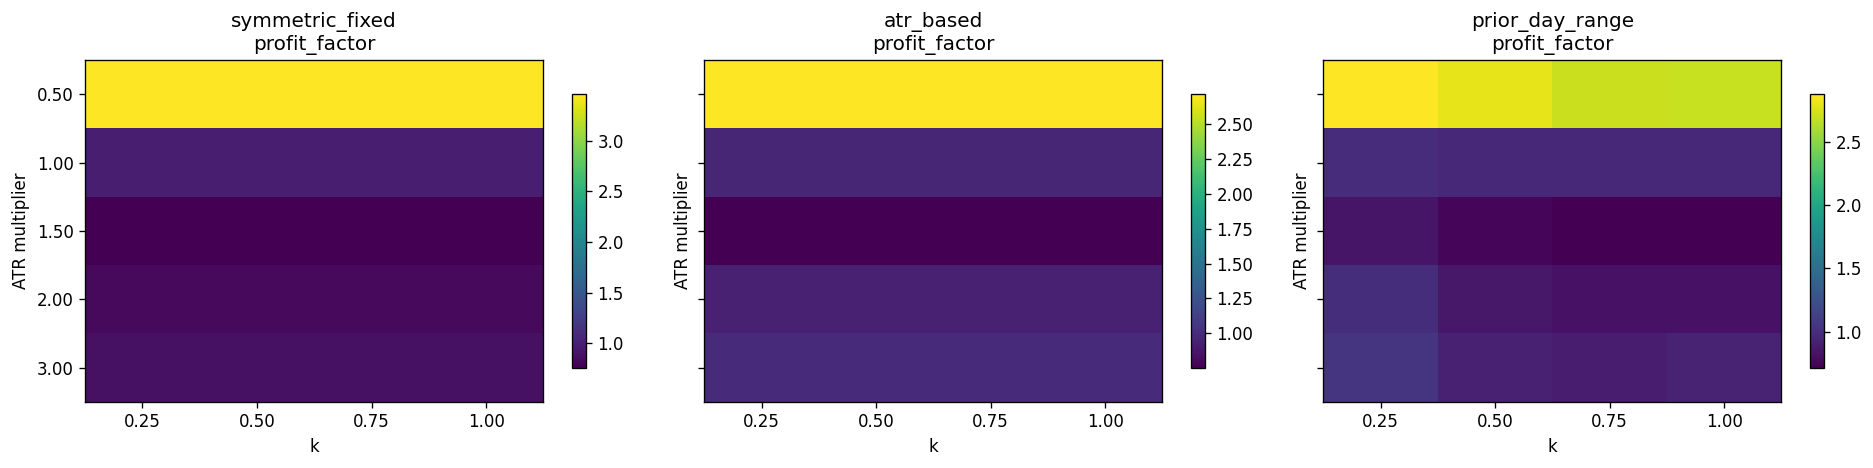

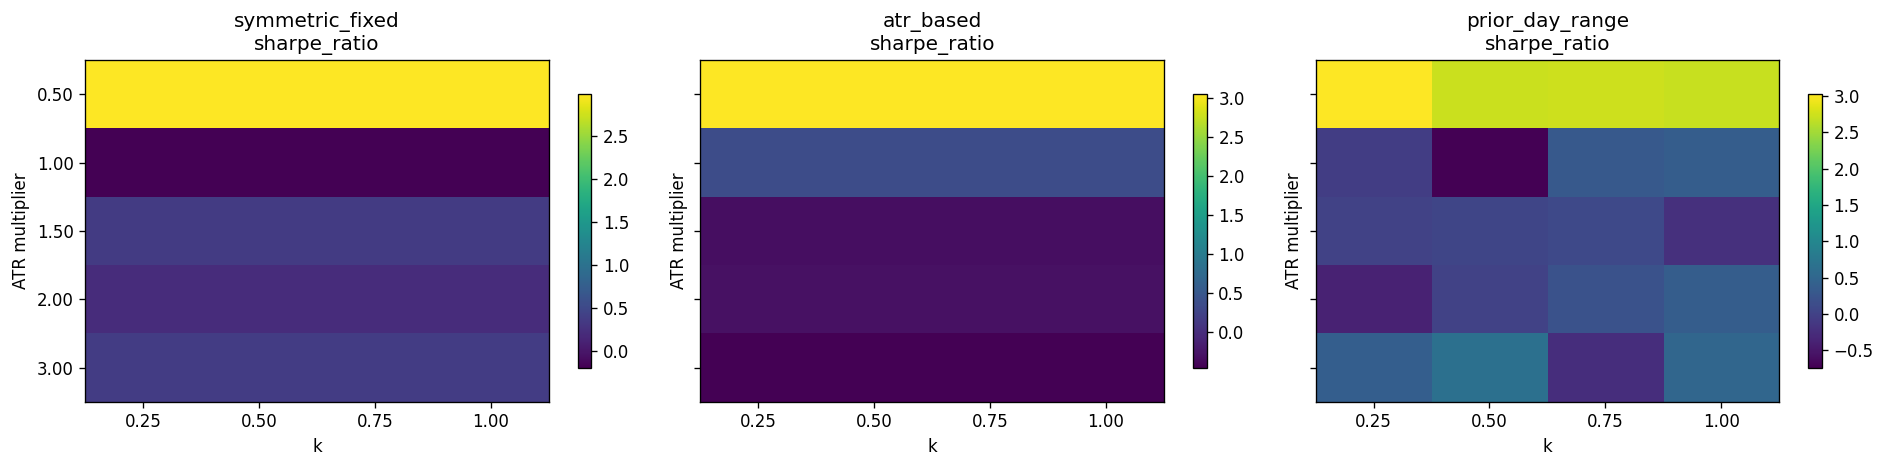

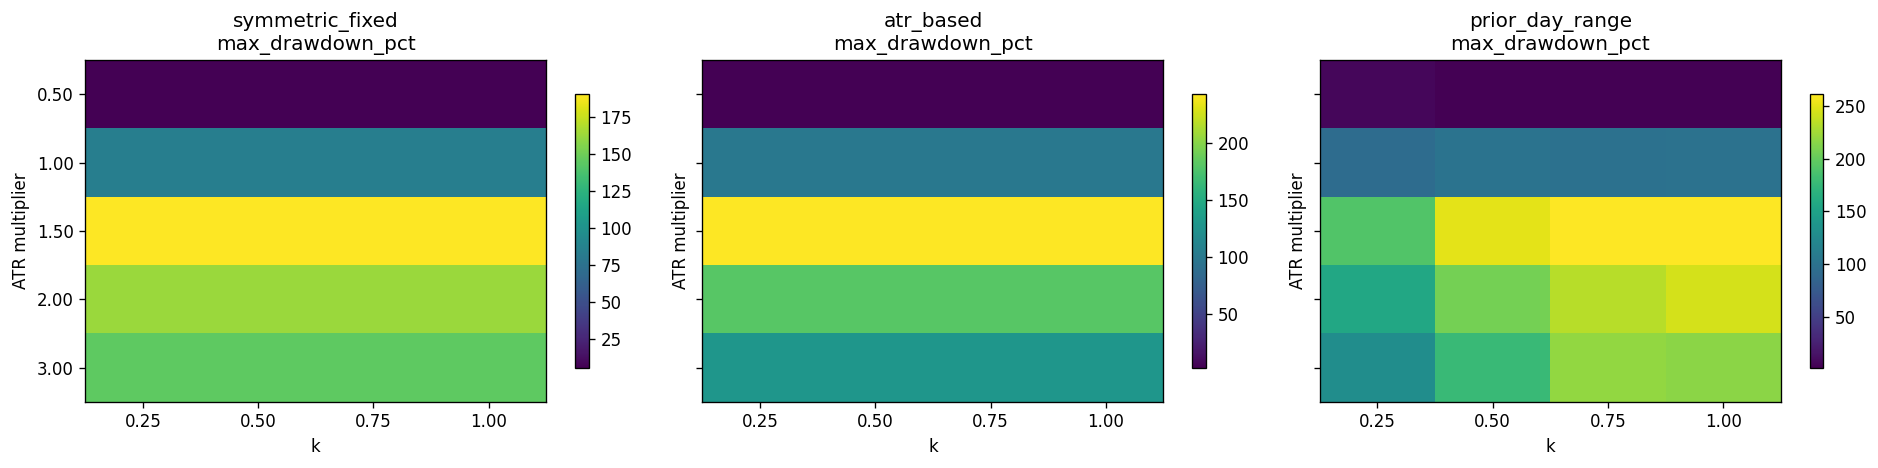

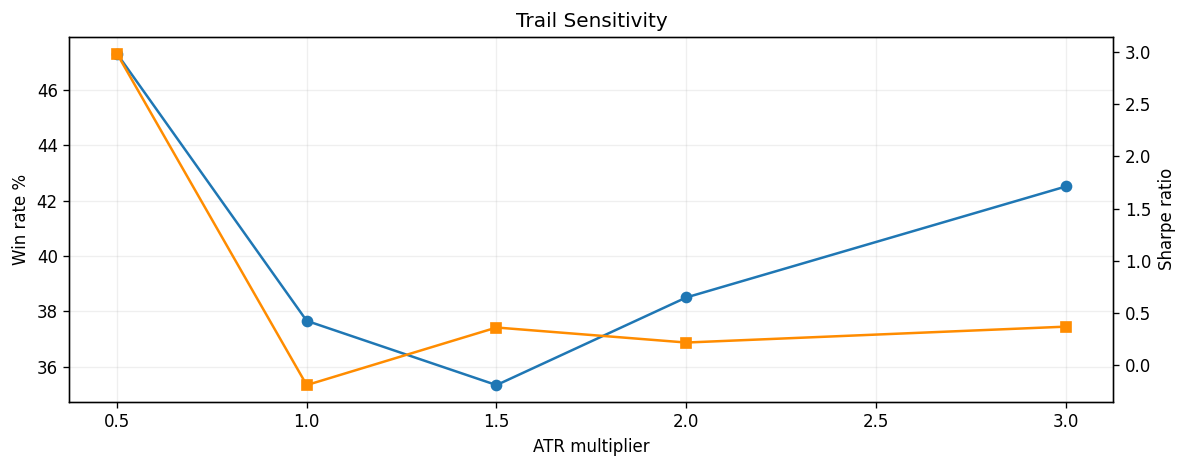

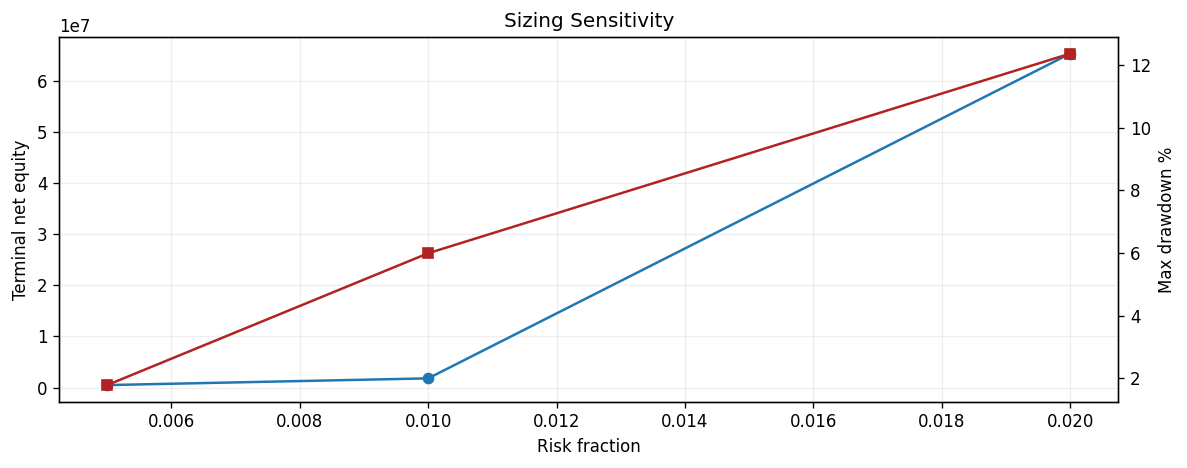

In [158]:
sensitivity_start = perf_counter()
sensitivity = run_sensitivity_analysis(feature_prepared, config)
sensitivity_elapsed = perf_counter() - sensitivity_start
print(f"Sensitivity runtime: {sensitivity_elapsed:.2f} seconds")

primary_grid = sensitivity["primary_grid"]
sizing_grid = sensitivity["sizing_grid"]

display(primary_grid.head(12))
display(sizing_grid)

for metric in ["win_rate", "profit_factor", "sharpe_ratio", "max_drawdown_pct"]:
    figure = plot_heatmap_grid(primary_grid, metric=metric, atr_period=config.atr_period)
    display(figure)
    plt.close(figure)

figure = plot_trail_sensitivity_curve(primary_grid, config)
display(figure)
plt.close(figure)

figure = plot_sizing_sensitivity_curve(sizing_grid)
display(figure)
plt.close(figure)


## 12. Validation and Unit Tests

The notebook fails fast if the audited invariants break. These are the core temporal-integrity, cost-accounting, and logging checks required by the plan, adapted where necessary to handle the approved rollover mechanics and the approved unadjusted-fill provenance audit.


In [13]:
display(result.validation_results)
assert (result.validation_results["status"] == "pass").all(), 'One or more validation checks failed.'


,test,status,detail
0,Signal temporal integrity,pass,Session-open breakout levels equal the previou...
1,ATR temporal integrity,pass,Shifted ATR equals the one-bar-lagged Wilder A...
2,Fill price series provenance,pass,All fills are explicitly tagged as sourced fro...
3,Roll continuity,pass,Adjusted close continuity at each roll is with...
4,Cost accounting,pass,Trade transaction costs equal base round-turn ...
5,Equity monotonicity check,pass,"Entries do not change equity, and each trade u..."
6,Minimum floor logging,pass,Every trade that used the one-contract floor a...
